# Perform Calibration of QuantiCam

In [1]:
# Load QuantiCam library
using QuantiCam

## Acquire Frames from Live Camera

In [2]:
# Setup connection to camera
if (@isdefined qc) && qc!== nothing
    # Try to reconfigure or cleanup and initialise from the begining
    try
        QuantiCam.reload_config(qc, "../config/tcspc.json")
        QuantiCam.config_sensor(qc)
    catch
        #QuantiCam.sensor_disconnect(qc)
        QuantiCam.cleanup!(qc)
    end
end
if !(@isdefined qc) || qc === nothing
    qc = load_qc(config_path="../config/tcspc.json")
end

Scanning USB for Opal Kelly devices...
Found 1 Opal Kelly device(s)
Serial number of device 0 is 1908000OVV


[ Info: Reloading active config
┌ Warning: Sensor not connected, cannot reconfigure
└ @ QuantiCam c:\Users\s2764691\Documents\PhD\quanticam.jl\src\setup.jl:251
[ Info: Opal Kelly to API Comms setup in progress...
[ Info: Device opened with id=Opal Kelly XEM7310 and board model=XEM7310-A200
[ Info: Located bit file \\csce.datastore.ed.ac.uk\csce\eng\groups\3D_VISION\ms_lidar/fw\photon_cnt_tcspc_xem7310-a200_v2.1.1.bit
[ Info: Firmware written successfuly
[ Info: Firmware revision: 2.1.1
[ Info: Waiting on voltages to stabilize
[ Info: Connected to Sensor
[ Info: Sensor configured with config "default" and STOP_CLK=3.125 MHz and phase: 300.0 degrees


QCBoard(OpalKelly.FPGA(0, Ptr{Nothing} @0x00000270388a4350, Ptr{Nothing} @0x0000000180000000, "XEM7310-A200", "\\\\csce.datastore.ed.ac.uk\\csce\\eng\\groups\\3D_VISION\\ms_lidar/fw\\photon_cnt_tcspc_xem7310-a200_v2.1.1.bit", UInt8[], false, 0), Dict{QuantiCam.BankEnum, QuantiCam.BankInfo}(QuantiCam.CHIP_RST => QuantiCam.BankInfo(0x40, 0x01, 0x04), QuantiCam.SYS_RST => QuantiCam.BankInfo(0x40, 0x01, 0x01), QuantiCam.ROW_ENABLES_2 => QuantiCam.BankInfo(0x09, 0x20, 0x00), QuantiCam.FPGA_LEDS => QuantiCam.BankInfo(0x16, 0x08, 0x00), QuantiCam.ROW_ENABLES_3 => QuantiCam.BankInfo(0x0a, 0x20, 0x00), QuantiCam.GLOBAL_SHUTTER_MODE => QuantiCam.BankInfo(0x04, 0x01, 0x00), QuantiCam.OUTPUT_MODE => QuantiCam.BankInfo(0x04, 0x02, 0x09), QuantiCam.TEST_COL_SECOND_PHOTON_MODE => QuantiCam.BankInfo(0x04, 0x01, 0x02), QuantiCam.START_CAPTURE_TRIGGER => QuantiCam.BankInfo(0x40, 0x01, 0x02), QuantiCam.FIFO_RST => QuantiCam.BankInfo(0x40, 0x01, 0x03)…), nothing, 1.1f0, 1.2f0, 1.1f0, 15.6f0, QuantiCam.Con

In [ ]:
# Load new config if needed
new_config!(qc, "tcspc", "../config/tcspc.json")

In [4]:
# Initialise the HDF5 (optional)
hdf5_filename = "../experiment/board_calibration.h5"
hdf5_task, hdf5_channel = QuantiCam.hdf5_collector_init(hdf5_filename, Matrix{UInt16}; description="Board placed at different distances for calibration")

[ Info: Spawning HDF5 collector thread
[ Info: Returning channel to caller


(Task (runnable, started) @0x0000027000ceb650, Channel{Union{QuantiCam.Terminate, Dict{String, Any}, QuantiCam.Clear, GroupConfig, Matrix{UInt16}}}(1))

In [43]:
# Create dataset group
number_of_frames = 1000
group_config = QuantiCam.GroupConfig("7", number_of_frames, "board placed at 45cm")
put!(hdf5_channel, group_config)

GroupConfig("7", 1000, "board placed at 45cm")

In [44]:
# Acqire TCSPC histograms from live camera
frames = QuantiCam.capture_frames(qc, number_of_frames; hdf_channel=hdf5_channel)
filtered_frames = map(frame -> QuantiCam.filter_code(frame, 0xffc), frames)
typeof(filtered_frames)

[ Info: Creating dataset for frames of type: UInt16 and size: (1000, 192, 128) in group: HDF5.Group: /7 (file: ../experiment/board_calibration.h5)


Vector{Matrix{Union{Missing, UInt16}}} (alias for Array{Array{Union{Missing, UInt16}, 2}, 1})

In [49]:
# Clean up
QuantiCam.cleanup!(qc)

[ Info: Disconnected from Sensor
[ Info: Cleaning up FPGA connection to OK FrontPanel
[ Info: FPGA desctructed! => Safe exit


## Load Data from HDF5 Files

In [ ]:
# Alternatively, load from HDF5 file
using HDF5

hdf5_filename = "../experiment/board_calibration.h5"
fid = h5open(hdf5_filename, "r")
group = fid["1"]
frames_h5 = read_dataset(group, "frames")
frames = collect(Matrix{UInt16}, eachslice(frames_h5, dims=1));
close(fid)
filtered_frames = map(frame -> QuantiCam.filter_code(frame, 0xffc), frames)
typeof(filtered_frames)

Vector{Matrix{Union{Missing, UInt16}}} (alias for Array{Array{Union{Missing, UInt16}, 2}, 1})

In [29]:
compensation_filename = "../experiment/compensated_depth_map.h5"
compensation_frame = h5read(compensation_filename, "compensation");

## Process and Visualise the Data

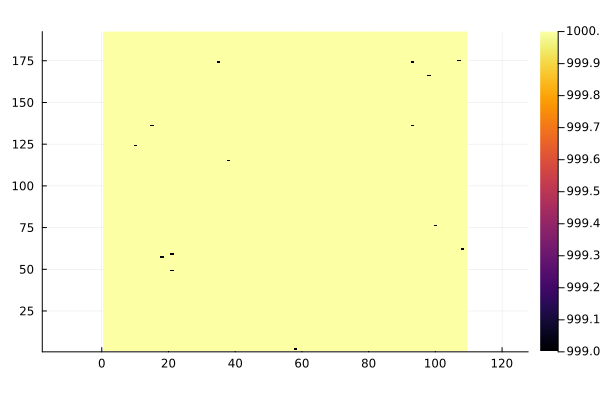

In [46]:
using Statistics
using Plots

# Collect frames into per-pixel vectors
tcspc_stream = QuantiCam.collect_frames(filtered_frames)
tcspc_mean = map(pixel -> mean(pixel), tcspc_stream)
tcspc_var = map(pixel -> var(pixel), tcspc_stream)

# Visualise the number of returns for each pixel
tcspc_events = map(pixel -> length(collect((skipmissing(pixel)))), tcspc_stream)
heatmap(tcspc_events[:,10:118], aspect_ratio = 0.5)

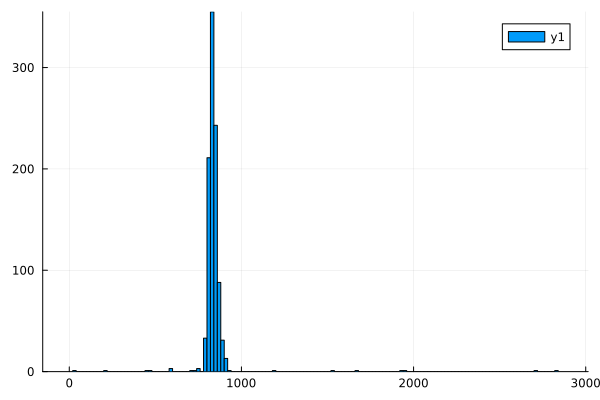

In [10]:
# Visualise a single pixel histogram
histogram(tcspc_stream[81, 64], bins=200)

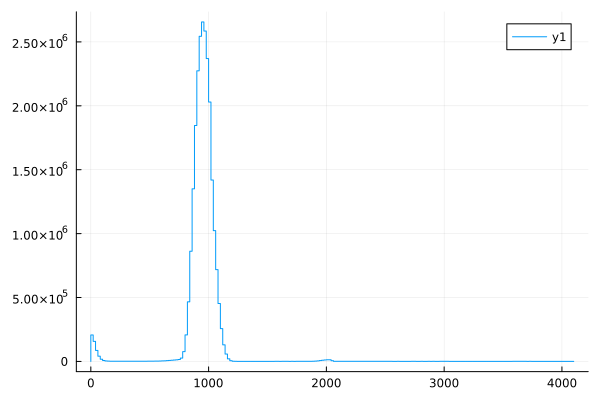

In [48]:
# Visualise the histogram of all pixel values
all_pixels = collect(Iterators.filter(x-> x>2.0, skipmissing(Iterators.flatten(tcspc_stream))))
histogram(all_pixels, bins=200)

Min depth: 55.90530691373017 at index CartesianIndex(18, 7)
Max depth: 71.61537910650931 at index CartesianIndex(47, 128)
Average depth: 60.1907828415435
Median depth: 60.27570614658112
Depth range: 15.710072192779137


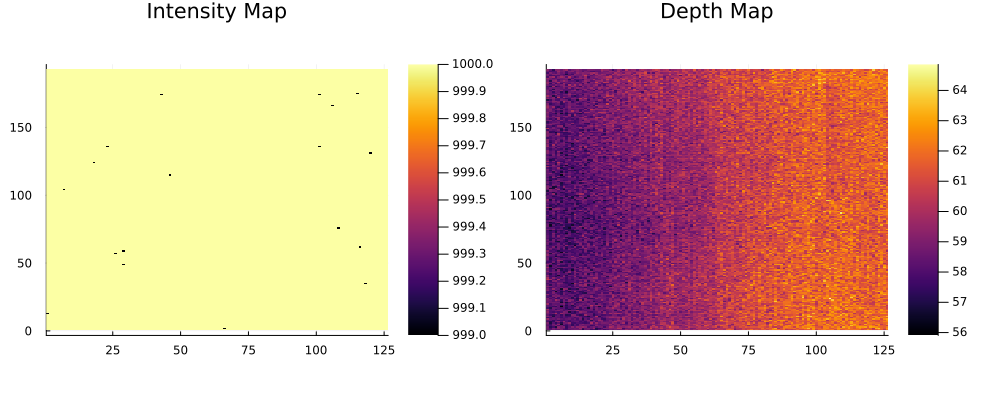

In [47]:
using Plots

time_histograms = QuantiCam.build_histogram(tcspc_stream, 256)
#time_histograms_cropped = [time_histograms[i, j][(1):(256)] for i in 1:size(time_histograms, 1), j in 1:size(time_histograms, 2)]
time_histograms_cropped = copy(time_histograms)
for i in 1:size(time_histograms, 1), j in 1:size(time_histograms, 2)
    time_histograms_cropped[i, j][1:10] .= 0
end
centroids = QuantiCam.decode_histogram_to_depth(time_histograms_cropped, 10)
#centroids = QuantiCam.decode_histogram_to_depth(time_histograms_cropped, 10, compensation_frame)
min_val, min_idx = findmin(ifelse.(isnan.(centroids), Inf, centroids)[:,1:128])
max_val, max_idx = findmax(ifelse.(isnan.(centroids), -Inf, centroids)[:,1:128])
avg_centroid_value = mean(filter(!isnan, centroids))
median_centroid_value = median(filter(!isnan, centroids))
println("Min depth: $min_val at index $min_idx")
println("Max depth: $max_val at index $max_idx")
println("Average depth: $avg_centroid_value")
println("Median depth: $median_centroid_value")
println("Depth range: $(max_val - min_val)")
intensity_img = heatmap(tcspc_events[:,2:127], colorbar=true, aspect_ratio = 0.5, title="Intensity Map")
depth_img = heatmap(centroids[:,2:127], colorbar=true, aspect_ratio=0.5, title="Depth Map")
plot(intensity_img, depth_img, layout = (1, 2), size=(1000, 400))

63.35738244403124

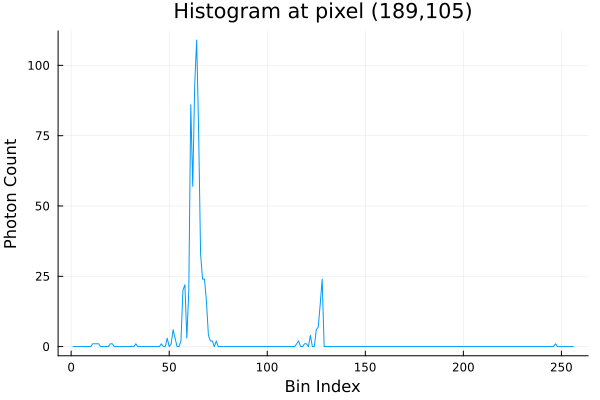

In [14]:
# Visualise (Sanity check)
i, j = 189, 105
h = time_histograms[i, j]
print(centroids[i, j])
plot(1:length(h), h,
     xlabel="Bin Index",
     ylabel="Photon Count",
     title="Histogram at pixel ($i,$j)",
     legend=false)

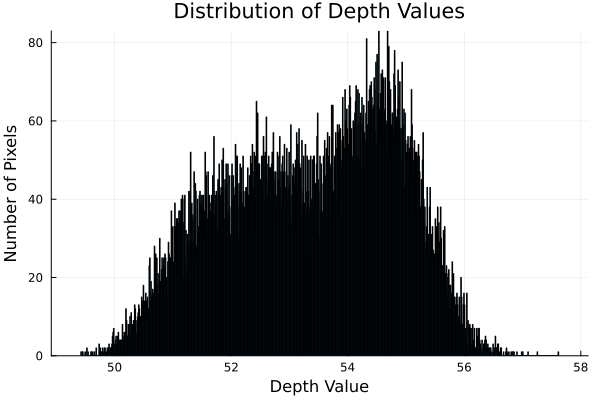

In [10]:
# Visualise the distribution of depth values
histogram(vec(centroid), bins=1000,
          xlabel="Depth Value",
          ylabel="Number of Pixels",
          title="Distribution of Depth Values",
          legend=false)

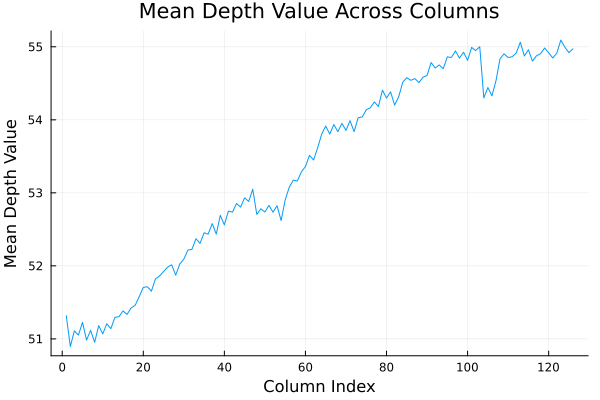

In [17]:
# Plot the column against the mean column value of centroid
avg_column = mean(centroid[:,2:127], dims=1)
#print the shape of avg_column
size(avg_column)
plot(1:length(avg_column), avg_column[:],
     xlabel="Column Index",
     ylabel="Mean Depth Value",
     title="Mean Depth Value Across Columns",
     legend=false)

49.8173190075479

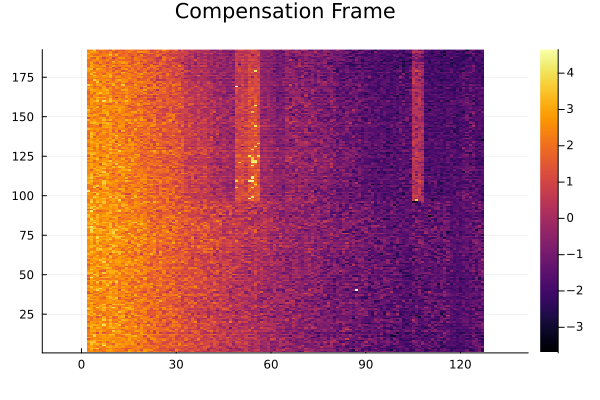

In [54]:
# Shift all pixels so that centroids value are the same
avg_centoid_value = mean(filter(!isnan, centroids))
print(avg_centoid_value)
compensation_frame = avg_centoid_value .- centroids
centroids_compensated = centroids .+ compensation_frame
heatmap(compensation_frame, colorbar=true, aspect_ratio=0.5, title="Compensation Frame")


File already exists!


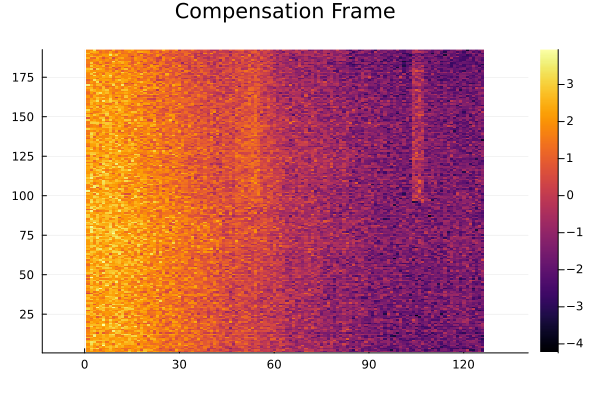

In [26]:
# Save compensation frame
if isfile("../experiment/compensated_depth_map.h5")
    println("File already exists!")
else
    h5open("../experiment/compensated_depth_map.h5", "w") do fid
        write(fid, "compensation", compensation_frame)
    end
end
heatmap(compensation_frame[:,2:127], colorbar=true, aspect_ratio=0.5, title="Compensation Frame")

## Calibrate

In [56]:
using HDF5

function browse_hdf5(obj, path="/")
    for name in keys(obj)
        fullpath = path == "/" ? "/" * name : path * "/" * name
        child = obj[name]

        if typeof(child) == HDF5.Group
            println("📁 Group: $fullpath")
            if haskey(attributes(child), "description")
                println("   📝 Description: ", read(attributes(child)["description"]))
            end
            browse_hdf5(child, fullpath)
        elseif typeof(child) == HDF5.Dataset
            println("📦 Dataset: $fullpath")
            println("   📐 Size: ", size(child))
            if haskey(attributes(child), "description")
                println("   📝 Description: ", read(attributes(child)["description"]))
            end
        else
            println("❓ Unknown object: $fullpath")
        end
    end
end

function inspect_hdf5_file(filename::String)
    h5open(filename, "r") do fid
        browse_hdf5(fid)
    end
end

inspect_hdf5_file("../experiment/board_calibration.h5")

📁 Group: /1
   📝 Description: board placed at 30cm
📦 Dataset: /1/frames
   📐 Size: (1000, 192, 128)
📦 Dataset: /1/start_time
   📐 Size: ()
📦 Dataset: /1/timestamp
   📐 Size: (1000,)
📁 Group: /2
   📝 Description: board placed at 60cm
📦 Dataset: /2/frames
   📐 Size: (1000, 192, 128)
📦 Dataset: /2/start_time
   📐 Size: ()
📦 Dataset: /2/timestamp
   📐 Size: (1000,)
📁 Group: /3
   📝 Description: board placed at 90cm
📦 Dataset: /3/frames
   📐 Size: (1000, 192, 128)
📦 Dataset: /3/start_time
   📐 Size: ()
📦 Dataset: /3/timestamp
   📐 Size: (1000,)
📁 Group: /4
   📝 Description: board placed at 120cm
📦 Dataset: /4/frames
   📐 Size: (1000, 192, 128)
📦 Dataset: /4/start_time
   📐 Size: ()
📦 Dataset: /4/timestamp
   📐 Size: (1000,)
📁 Group: /5
   📝 Description: board placed at 120cm
📦 Dataset: /5/frames
   📐 Size: (1000, 192, 128)
📦 Dataset: /5/start_time
   📐 Size: ()
📦 Dataset: /5/timestamp
   📐 Size: (1000,)
📁 Group: /6
   📝 Description: board placed at 30cm
📦 Dataset: /6/frames
   📐 Size: (1000

In [ ]:
using HDF5

function update_description(h5_filename::String, path::String, new_description::String)
    h5open(h5_filename, "r+") do fid
        obj = fid[path]

        # Delete existing attribute using HDF5 C API binding if it exists
        if haskey(attributes(obj), "description")
            HDF5.h5a_delete(obj, "description")
        end

        # Now write the new description
        attributes(obj)["description"] = new_description
        println("✅ Updated description at $path")
    end
end

#update_description("../experiment/board_calibration.h5", "/4", "Board placed at 90cm")

LoadError: MethodError: no method matching delete!(::HDF5.Attributes, ::String)
The function `delete!` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  delete!([91m::RecipesPipeline.DefaultsDict[39m, ::Any)
[0m[90m   @[39m [35mRecipesPipeline[39m [90mC:\Users\s2764691\.julia\packages\RecipesPipeline\BGM3l\src\[39m[90m[4mutils.jl:33[24m[39m
[0m  delete!([91m::Base.EnvDict[39m, ::AbstractString)
[0m[90m   @[39m [90mBase[39m [90m[4menv.jl:174[24m[39m
[0m  delete!([91m::EzXML.Node[39m, ::AbstractString)
[0m[90m   @[39m [36mEzXML[39m [90mC:\Users\s2764691\.julia\packages\EzXML\qbIRq\src\[39m[90m[4mnode.jl:1246[24m[39m
[0m  ...


In [27]:
# Alternatively, load from HDF5 file
using QuantiCam
using HDF5

hdf5_filename = "../experiment/board_cristy.h5"
fid = h5open(hdf5_filename, "r")
group = fid["first"]
frames_h5 = read_dataset(group, "frames")
frames1 = collect(Matrix{UInt16}, eachslice(frames_h5, dims=1));
group = fid["second"]
frames_h5 = read_dataset(group, "frames")
frames2 = collect(Matrix{UInt16}, eachslice(frames_h5, dims=1));
group = fid["third"]
frames_h5 = read_dataset(group, "frames")
frames3 = collect(Matrix{UInt16}, eachslice(frames_h5, dims=1));
close(fid)
# Filter the frames for valid TCSPC codes
filtered_frames1 = map(frame -> QuantiCam.filter_code(frame, 0xffc), frames1)
filtered_frames2 = map(frame -> QuantiCam.filter_code(frame, 0xffc), frames2)
filtered_frames3 = map(frame -> QuantiCam.filter_code(frame, 0xffc), frames3)
# Collect frames into per-pixel vectors
tcspc_stream1 = QuantiCam.collect_frames(filtered_frames1)
tcspc_stream2 = QuantiCam.collect_frames(filtered_frames2)
tcspc_stream3 = QuantiCam.collect_frames(filtered_frames3)

192×128 Matrix{Vector{Union{Missing, UInt16}}}:
 [missing, missing, missing, missing, missing, missing, missing, missing, missing, missing  …  missing, missing, missing, missing, missing, missing, missing, missing, missing, missing]  …  [missing, missing, missing, missing, missing, missing, missing, missing, missing, missing  …  missing, missing, missing, missing, missing, missing, missing, missing, missing, missing]
 [missing, missing, missing, missing, missing, missing, missing, missing, missing, missing  …  missing, missing, missing, missing, missing, missing, missing, missing, missing, missing]     [missing, missing, missing, missing, missing, missing, missing, missing, missing, missing  …  missing, missing, missing, missing, missing, missing, missing, missing, missing, missing]
 [missing, missing, missing, missing, missing, missing, missing, missing, missing, missing  …  missing, missing, missing, missing, missing, missing, missing, missing, missing, missing]     [missing, missing

Median ROI Depths:
Dataset 1: 61.029655648189205
Dataset 2: 59.1625017714772
Dataset 3: 57.34583339566901
-7.519592408209411e-17


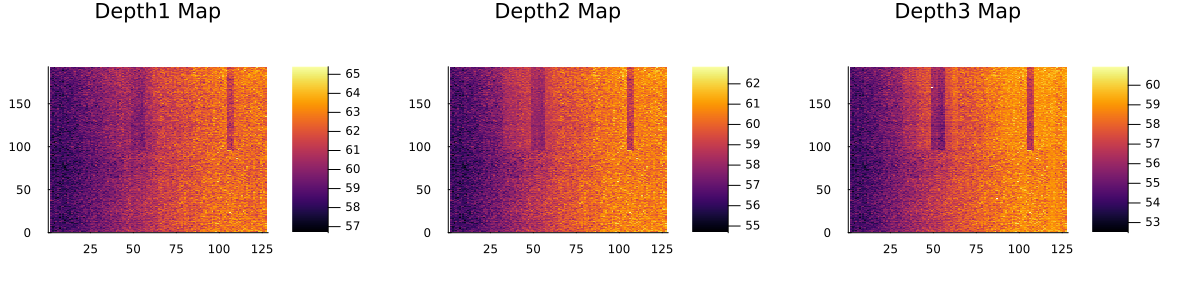

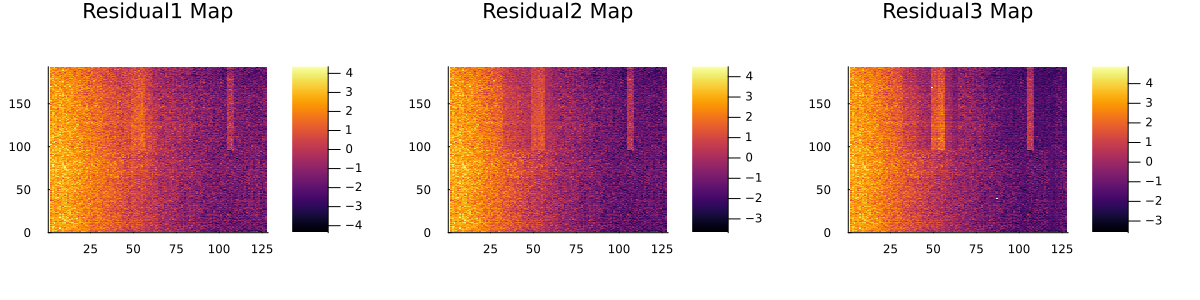

In [52]:
# Build and decode histograms for each dataset
hist1 = QuantiCam.build_histogram(tcspc_stream1, 256)
hist2 = QuantiCam.build_histogram(tcspc_stream2, 256)
hist3 = QuantiCam.build_histogram(tcspc_stream3, 256)
for i in 1:size(hist1, 1), j in 1:size(hist1, 2)
    hist1[i, j][1:10] .= 0
    hist2[i, j][1:10] .= 0
    hist3[i, j][1:10] .= 0
end
centroids1 = QuantiCam.decode_histogram_to_depth(hist1, 15)
centroids2 = QuantiCam.decode_histogram_to_depth(hist2, 15)
centroids3 = QuantiCam.decode_histogram_to_depth(hist3, 15)
# Compute the median depth in a central ROI for each dataset
centre_roi = (86:106, 54:74)
#median_roi_1 = median(filter(!isnan, centroids1[centre_roi...]))
#median_roi_2 = median(filter(!isnan, centroids2[centre_roi...]))
#median_roi_3 = median(filter(!isnan, centroids3[centre_roi...]))
median_roi_1 = median(filter(!isnan, centroids1))
median_roi_2 = median(filter(!isnan, centroids2))
median_roi_3 = median(filter(!isnan, centroids3))
println("Median ROI Depths:")
println("Dataset 1: $median_roi_1")
println("Dataset 2: $median_roi_2")
println("Dataset 3: $median_roi_3")
# Calculate residuals from the median ROI depth for each dataset (using the same convention as before)
residual1 = median_roi_1 .- centroids1
residual2 = median_roi_2 .- centroids2
residual3 = median_roi_3 .- centroids3
# Compute the average residual across the three datasets
average_residual = (residual1 .+ residual2 .+ residual3) ./ 3
residual = average_residual .- mean(filter(!isnan, average_residual))
println(mean(filter(!isnan, residual)))
# Visualise the raw depth map
depth1 = heatmap(centroids1, colorbar=true, aspect_ratio=0.5, title="Depth1 Map")
depth2 = heatmap(centroids2, colorbar=true, aspect_ratio=0.5, title="Depth2 Map")
depth3 = heatmap(centroids3, colorbar=true, aspect_ratio=0.5, title="Depth3 Map")
depth_plot = plot(depth1, depth2, depth3, layout = (1, 3), size=(1200, 300))
display(depth_plot)
# Visualise the residual correction map
residual1 = heatmap(residual1, colorbar=true, aspect_ratio=0.5, title="Residual1 Map")
residual2 = heatmap(residual2, colorbar=true, aspect_ratio=0.5, title="Residual2 Map")
residual3 = heatmap(residual3, colorbar=true, aspect_ratio=0.5, title="Residual3 Map")
plot(residual1, residual2, residual3, layout = (1, 3), size=(1200, 300))

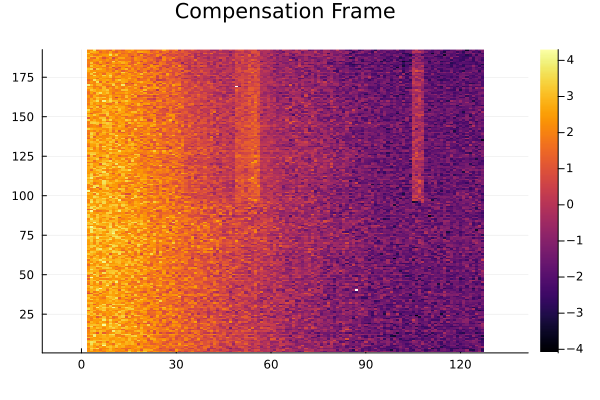

In [40]:
# Save compensation frame
if isfile("../experiment/compensated_depth_map.h5")
    println("File already exists!")
else
    h5open("../experiment/compensated_depth_map.h5", "w") do fid
        write(fid, "compensation", residual)
    end
end
heatmap(residual[:,1:128], colorbar=true, aspect_ratio=0.5, title="Compensation Frame")

Min depth: 59.852583293839295 at index CartesianIndex(169, 43)
Max depth: 61.97627533939493 at index CartesianIndex(185, 106)
60.8947058511481
Min depth: 58.31775728541914 at index CartesianIndex(125, 89)
Max depth: 59.713167614084746 at index CartesianIndex(110, 49)
58.921621397009936
Min depth: 55.72124599700375 at index CartesianIndex(110, 53)
Max depth: 57.98599250727449 at index CartesianIndex(169, 43)
57.044905367397206


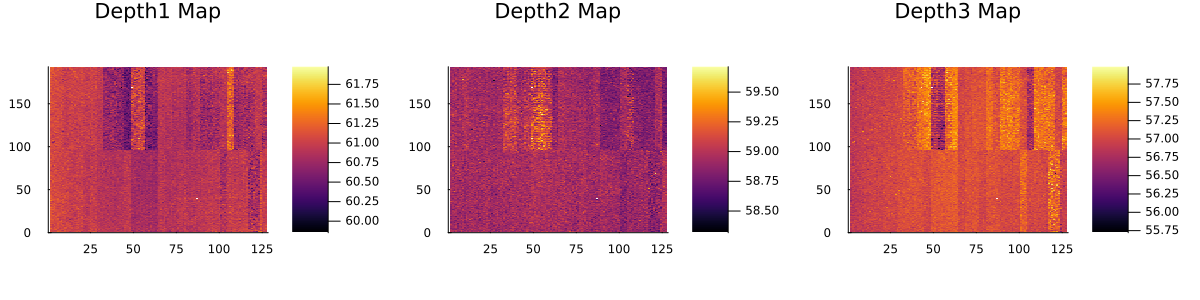

In [ ]:
# Load the compensation frame and apply it 
compensated_centroids1 = centroids1 .+ residual
compensated_centroids2 = centroids2 .+ residual
compensated_centroids3 = centroids3 .+ residual
# Caluclate the min max value and visualise the compensated centroids
min_val, min_idx = findmin(ifelse.(isnan.(compensated_centroids1), Inf, compensated_centroids1))
max_val, max_idx = findmax(ifelse.(isnan.(compensated_centroids1), -Inf, compensated_centroids1))
println("Min depth: $min_val at index $min_idx")
println("Max depth: $max_val at index $max_idx")
println(median(filter(!isnan, compensated_centroids1)))
min_val, min_idx = findmin(ifelse.(isnan.(compensated_centroids2), Inf, compensated_centroids2))
max_val, max_idx = findmax(ifelse.(isnan.(compensated_centroids2), -Inf, compensated_centroids2))
println("Min depth: $min_val at index $min_idx")
println("Max depth: $max_val at index $max_idx")
println(median(filter(!isnan, compensated_centroids2)))
min_val, min_idx = findmin(ifelse.(isnan.(compensated_centroids3), Inf, compensated_centroids3))
max_val, max_idx = findmax(ifelse.(isnan.(compensated_centroids3), -Inf, compensated_centroids3))
println("Min depth: $min_val at index $min_idx")
println("Max depth: $max_val at index $max_idx")
println(median(filter(!isnan, compensated_centroids3)))
depth1 = heatmap(compensated_centroids1, colorbar=true, aspect_ratio=0.5, title="Compensated depth1 Map")
depth2 = heatmap(compensated_centroids2, colorbar=true, aspect_ratio=0.5, title="Compensated depth2 Map")
depth3 = heatmap(compensated_centroids3, colorbar=true, aspect_ratio=0.5, title="Compensated depth3 Map")
plot(depth1, depth2, depth3, layout = (1, 3), size=(1200, 300))